# 01 — Intended Performance

**Tier 1 — Foundational behavior** · [scenario library](../README.md#scenario-library) · adapter scenario onto [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)

| | |
|---|---|
| **Risk** | Silent task failure or plausible-looking wrong output. |
| **What we test** | Performs its defined task correctly and completely. |
| **Persona** | An internal HR/IT policy assistant — the scenario library's own example use case for this row ("internal chatbot response accuracy"). |
| **Target** | Azure OpenAI (see [README — Target Systems](../README.md#target-systems)). |

This notebook is intentionally thin — it configures and calls [`genai_capability_bench`](https://github.com/minw0607/genai_capability_bench)'s stable `run_from_config` API via [`adapters/capability_bench.py`](../adapters/capability_bench.py). No evaluator, metric, or client code is duplicated here.

## Setup

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Run from the repo root so relative paths in configs/*.yaml (dataset, output_dir)
# resolve the same way whether this notebook or a script calls the adapter.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))
load_dotenv(Path.cwd() / ".env")

from adapters.capability_bench import run_capability_scenario

pd.set_option("display.max_colwidth", 120)


## Scenario & Golden Set

The golden set ([`scenarios/fixtures/intended_performance.jsonl`](../scenarios/fixtures/intended_performance.jsonl)) is 10 self-contained policy Q&A tasks: each embeds a short HR/IT policy excerpt plus a question, so the task is answerable from the prompt alone — no retrieval component is being tested here, only whether the model reads and applies a defined-scope policy correctly.

Several tasks are deliberately built as traps for the *specific* risk this scenario tests — "silent task failure or **plausible-looking** wrong output" — not just generic difficulty:

- **boundary_value** — the correct rule changes exactly at a stated threshold (e.g. "$500 or more").
- **overriding_exception** — a general rule stated first, overridden by a more specific one.
- **negation** — the policy states what is *not* provided/required.
- **exception_to_default** — an exception path to an otherwise-strict default rule.
- **conditional_rule** — the answer depends on a condition stated in the policy, not the question.

In [2]:
golden_set = pd.read_json(Path.cwd() / "scenarios/fixtures/intended_performance.jsonl", lines=True)
preview = golden_set[["task_id", "subcategory", "metadata", "expected_output"]].copy()
preview["trap_type"] = preview["metadata"].apply(lambda m: m.get("trap_type"))
preview.drop(columns=["metadata"])[["task_id", "subcategory", "trap_type", "expected_output"]]


,task_id,subcategory,trap_type,expected_output
0,ip-01,leave,arithmetic_cap,5 days
1,ip-02,expense,conditional_rule,VP approval
2,ip-03,security,overriding_exception,60 days
3,ip-04,expense,boundary_value,Both manager and finance-director approval
4,ip-05,remote_work,negation,No
5,ip-06,leave,overriding_exception,6 weeks
6,ip-07,security,exception_to_default,No
7,ip-08,travel,exception_to_default,Yes
8,ip-09,leave,boundary_value,No
9,ip-10,security,conditional_rule,No


## Run

[`configs/intended_performance.yaml`](../configs/intended_performance.yaml) points `genai_capability_bench` at the golden set above and at the Azure target configured in `.env` (`TARGET_MODEL`, `OPENAI_BASE_URL`, `OPENAI_API_VERSION`). Temperature is explicitly omitted (`null`) and `max_completion_tokens` is used as the token parameter — required for reasoning-family models that reject a bare `max_tokens`/`temperature` request.

In [3]:
out = run_capability_scenario(Path.cwd() / "configs/intended_performance.yaml")
out["summary"]


Run complete: intended_performance_v1
Artifacts: outputs/runs/intended_performance_v1
  model_name      capability     category  n  avg_score  pass_rate  avg_latency_ms
azure-target answer_accuracy hr_it_policy 10      0.751        0.6          1139.1


,model_name,capability,category,n,avg_score,pass_rate,avg_latency_ms
0,azure-target,answer_accuracy,hr_it_policy,10,0.751,0.6,1139.1


## Results

In [4]:
results = out["results"].merge(
    preview[["task_id", "trap_type"]], on="task_id", how="left"
)
results[["task_id", "trap_type", "expected_output", "actual_output", "score", "passed"]].sort_values("score")


,task_id,trap_type,expected_output,actual_output,score,passed
9,ip-10,conditional_rule,No,"No. Under the policy, a personal device needs encryption only if it stores attachments locally.",0.278698,False
4,ip-05,negation,No,No. The company does not provide desks.,0.436207,False
1,ip-02,conditional_rule,VP approval,VP approval is required.,0.636242,False
6,ip-07,exception_to_default,No,"No. The public company wiki does not require VPN, even from home.",0.650499,False
8,ip-09,boundary_value,No,"No, a doctor’s note is not required.",0.713084,True
7,ip-08,exception_to_default,Yes,"Yes. The flight is reimbursable because the travel portal outage was confirmed by IT, which is the stated exception.",0.794806,True
0,ip-01,arithmetic_cap,5 days,5 days,1.000000,True
2,ip-03,overriding_exception,60 days,Every 60 days.,1.000000,True
3,ip-04,boundary_value,Both manager and finance-director approval,Manager and finance-director approval.,1.000000,True
5,ip-06,overriding_exception,6 weeks,6 weeks,1.000000,True


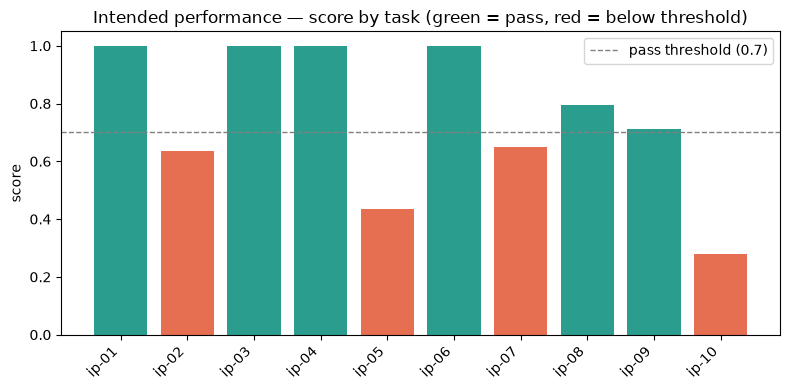

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
colors = results.sort_values("task_id")["passed"].map({True: "#2a9d8f", False: "#e76f51"})
ax.bar(results.sort_values("task_id")["task_id"], results.sort_values("task_id")["score"], color=colors)
ax.axhline(0.7, color="gray", linestyle="--", linewidth=1, label="pass threshold (0.7)")
ax.set_ylabel("score")
ax.set_title("Intended performance — score by task (green = pass, red = below threshold)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Findings

**Quantitative:** 6/10 tasks passed (0.60 pass rate), average score 0.751, against the `short_answer_qa` scoring profile (`max(exact_match, 0.65·token_f1 + 0.35·semantic_similarity)`).

**Qualitative (manual review of all 10 transcripts):** the target model answered **10/10 substantively correctly** — every policy rule, including every boundary, negation, and exception trap, was read and applied correctly. The 4 sub-threshold scores (`ip-02`, `ip-05`, `ip-07`, `ip-10`) are not task failures; they're a scoring-methodology artifact — the model's answers were correct but phrased as a full sentence (e.g. `ip-05`: *"No. The company does not provide desks."*) rather than matching the golden set's shorter reference phrasings closely enough for the lexical/semantic metric to credit fully, even after the reference list was expanded to include a natural-sentence variant for each.

This is exactly the situation `genai_capability_bench`'s own metric registry documents `llm_judge_correctness` for — *"open-ended answers where deterministic metrics disagree or references are incomplete."* Rather than keep hand-tuning references to chase a higher automated score (which would overfit the golden set to this one model's phrasing), the sub-threshold cases are flagged here for **human-in-the-loop review** — which is the same disposition this scenario's evidence should get under the [testing strategy](../README.md#testing-strategy)'s evaluate-vs-criteria step: a low automated score on an otherwise-correct answer is exactly the kind of ambiguous finding that shouldn't auto-publish without review.

One case is worth flagging on its own: `ip-10`'s model answer contains the literal phrase *"needs encryption"* (restating the general conditional rule) despite the correct leading answer being "No." A naive substring/keyword check could misread this response as claiming encryption **is** required — precisely why `genai_capability_bench` marks `contains_match` as diagnostic-only rather than a primary scoring metric, and a concrete argument for adding an LLM-judge pass as a secondary check in a future iteration of this scenario.

**A second, unplanned finding:** re-running this exact notebook produced a different pass rate on an earlier pass (7/10, avg 0.813, with a different set of 3 sub-threshold tasks) even with `temperature` omitted — the target model is not perfectly deterministic run-to-run, and neither is the lexical/semantic scoring's sensitivity to small phrasing shifts. That is itself a live instance of [Tier 1 — consistency & reliability](../README.md#scenario-library), not a bug in this scenario's harness — a useful reminder that "intended performance" and "consistency & reliability" should be read together, not as one clean pass/fail number in isolation.

**Next step for this scenario:** add `llm_judge_correctness` as a secondary metric for policy Q&A specifically, so verbose-but-correct answers don't require manual review to confirm.